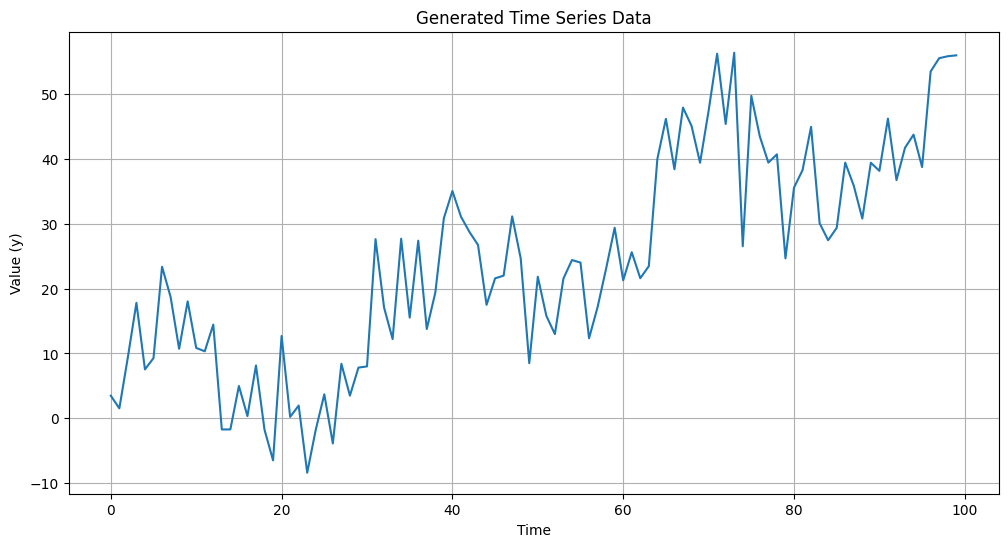

Generated time series 'y' with length: 100
First 5 values of y: [ 3.47699907  1.5188432   9.42800319 17.80763373  7.53448729]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate time points
t = np.arange(0, 100)

# Define a trend component
trend = 0.5 * t

# Define a seasonal component (e.g., sine wave)
seasonality = 10 * np.sin(t / 5)

# Define some random noise
np.random.seed(42) # for reproducibility
noise = np.random.normal(0, 7, len(t))

# Combine components to create the time series data
y = trend + seasonality + noise

# Plot the generated time series
plt.figure(figsize=(12, 6))
plt.plot(t, y)
plt.title('Generated Time Series Data')
plt.xlabel('Time')
plt.ylabel('Value (y)')
plt.grid(True)
plt.show()

print("Generated time series 'y' with length:", len(y))
print("First 5 values of y:", y[:5])

<h1>Etude Statistique <h1>

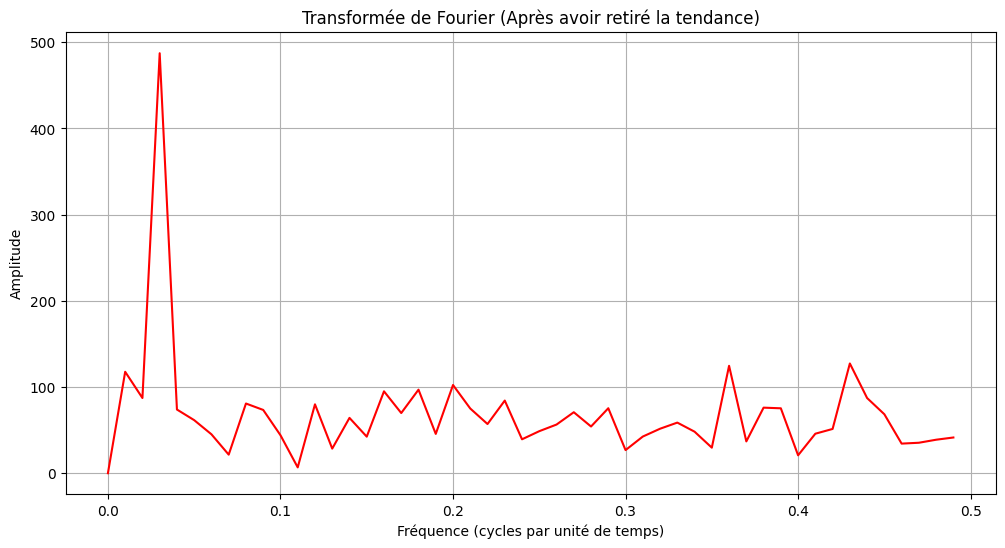

In [ ]:
from scipy import signal
y_sans_trend = signal.detrend(y)
n = len(y_sans_trend) # Define n as the length of the detrended signal
f = np.fft.fft(y_sans_trend) # Perform FFT on the detrended signal
frequence = np.fft.fftfreq(n)
demi_n = n // 2
f_pos = f[:demi_n]
freqs_pos = frequence[:demi_n]
plt.figure(figsize=(12, 6))
plt.plot(freqs_pos, np.abs(f_pos), color='red')
plt.title('Transformée de Fourier (Après avoir retiré la tendance)')
plt.xlabel('Fréquence (cycles par unité de temps)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


In [ ]:
# 1. On trouve la position (l'index) du plus grand pic
index_pic = np.argmax(np.abs(f_pos))

# 2. On trouve l'amplitude (la hauteur du pic sur l'axe Y)
amplitude_max = np.abs(f_pos)[index_pic]
# (Note : c'est mathématiquement la même chose que np.max(np.abs(f_pos)))

# 3. On trouve la fréquence correspondante (sur l'axe X)
frequence_pic = freqs_pos[index_pic]

print(f"Amplitude du pic (force de la saisonnalité) : {amplitude_max:.2f}")
print(f"Fréquence de la saisonnalité : {frequence_pic:.4f} cycles par unité de temps")

# 4. On déduit la longueur du cycle (la Période T)
if frequence_pic > 0:
    periode = 1 / frequence_pic
    print(f"Le cycle se répète exactement tous les {periode:.2f} pas de temps.")

Amplitude du pic (force de la saisonnalité) : 487.21
Fréquence de la saisonnalité : 0.0300 cycles par unité de temps
Le cycle se répète exactement tous les 33.33 pas de temps.


<Figure size 1200x600 with 0 Axes>

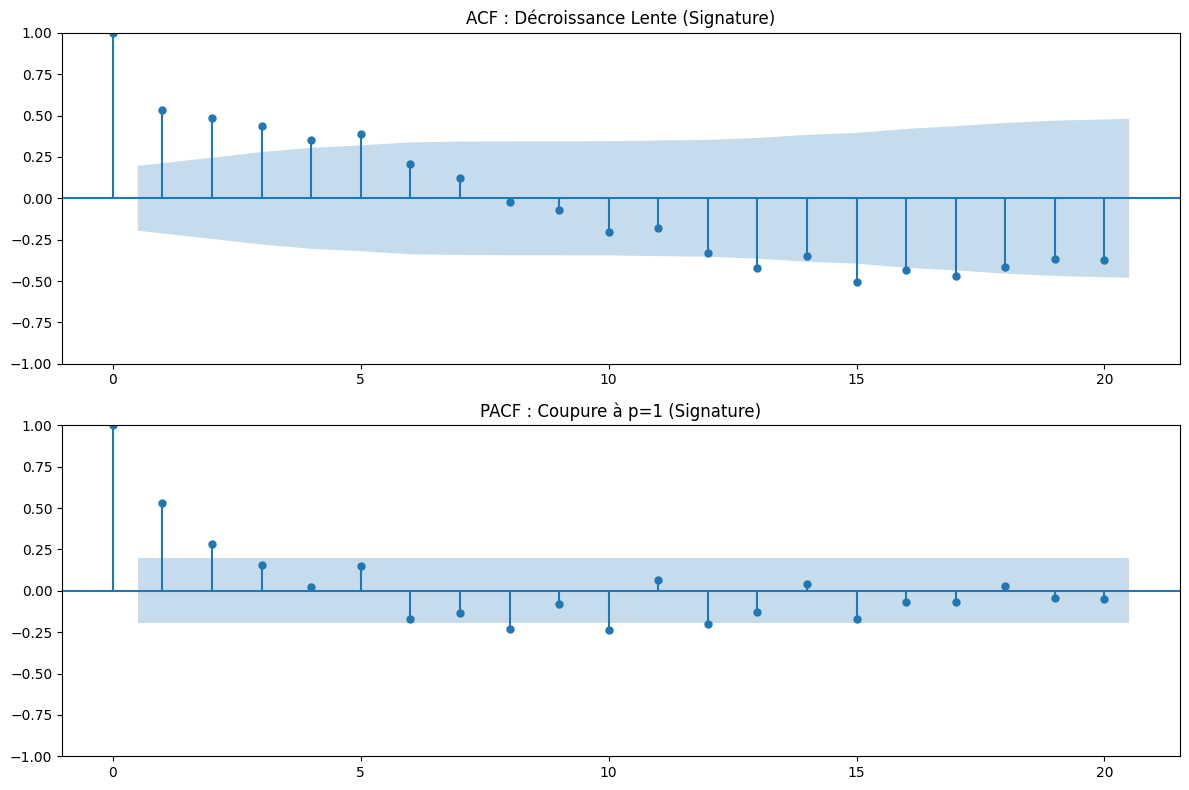

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf

plt.figure(figsize=(12, 6))
# Create subplots for ACF and PACF
fig, ax= plt.subplots(2, 1, figsize=(12, 8))

# Plot ACF using the imported plot_acf function
plot_acf(y_sans_trend, lags=20, ax=ax[0], title="ACF : Décroissance Lente (Signature)")

# Plot PACF using the imported plot_pacf function
plot_pacf(y_sans_trend, lags=20, ax=ax[1], title="PACF : Coupure à p=1 (Signature)")

plt.tight_layout()
plt.show()

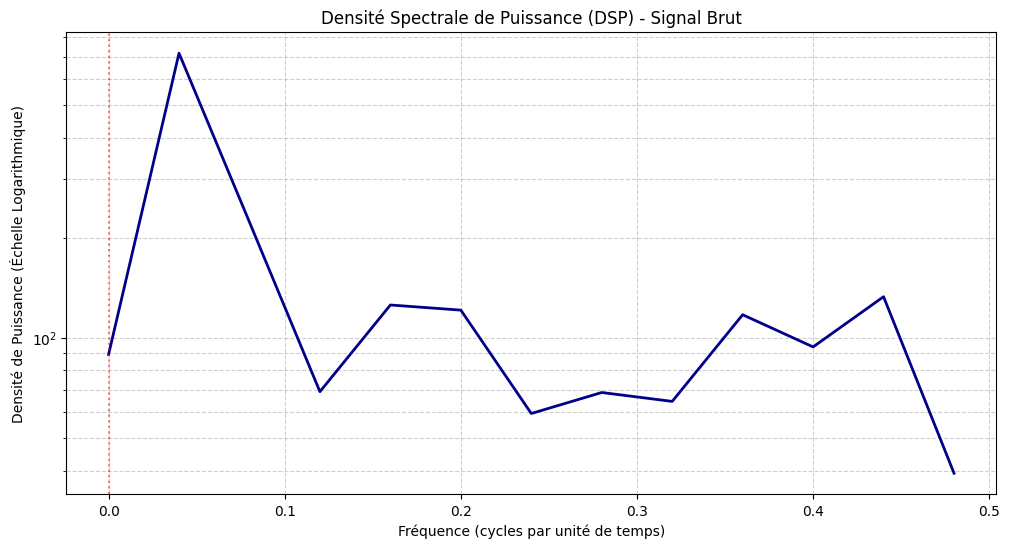

In [ ]:
# nperseg définit la taille de la fenêtre de Welch (ici un quart de tes données)

freqs, dsp = signal.welch(y, fs=1.0, window='hann', nperseg=len(y)//4)
plt.figure(figsize=(12, 6))
# On utilise semilogy pour que les petites fréquences ne soient pas invisibles
plt.semilogy(freqs, dsp, color='darkblue', linewidth=2)

plt.title('Densité Spectrale de Puissance (DSP) - Signal Brut')
plt.xlabel('Fréquence (cycles par unité de temps)')
plt.ylabel('Densité de Puissance (Échelle Logarithmique)')
plt.grid(True, which="both", ls="--", alpha=0.6)

# On met en évidence l'axe vertical à 0 pour bien voir le pic de la tendance
plt.axvline(x=0, color='red', linestyle=':', alpha=0.5)

plt.show()

### STATICSTICAL TEST

In [ ]:
# ADF, KPSS, and PP Tests
from statsmodels.tsa.stattools import adfuller, kpss
%pip install arch # Corrected typo and specified library for PP test

from arch.unitroot import PhillipsPerron


import numpy as np

# Perform ADF test on 'y'
adf_result = adfuller(y)
adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

# Interpret ADF test result
print("ADF Test (on y):")
print(f"  ADF Statistic: {adf_statistic:.2f}")
print(f"  P-value: {adf_pvalue:.3f}")
if adf_pvalue <= 0.05:
    print("  Result: The series is likely stationary. ✅")
else:
    print("  Result: The series is likely non-stationary. ❌")

# Perform KPSS test on 'y'
kpss_result = kpss(y, regression='c') # 'c' for constant
kpss_statistic = kpss_result[0]
kpss_pvalue = kpss_result[1]

# Interpret KPSS test result
print("\nKPSS Test (on y):")
print(f"  KPSS Statistic: {kpss_statistic:.2f}")
print(f"  P-value: {kpss_pvalue:.3f}")
if kpss_pvalue >= 0.05:
    print("  Result: The series is likely stationary. ✅")
else:
    print("  Result: The series is likely non-stationary. ❌")

# Perform Phillips-Perron (PP) test on 'y'
pp_result = PhillipsPerron(y)
pp_statistic = pp_result.stat
pp_pvalue = pp_result.pvalue

# Interpret PP test result
print("\nPhillips-Perron (PP) Test (on y):")
print(f"  PP Statistic: {pp_statistic:.2f}")
print(f"  P-value: {pp_pvalue:.3f}")
if pp_pvalue <= 0.05:
    print("  Result: The series is likely stationary. ✅")
else:
    print("  Result: The series is likely non-stationary. ❌")

ADF Test (on y):
  ADF Statistic: -0.50
  P-value: 0.892
  Result: The series is likely non-stationary. ❌

KPSS Test (on y):
  KPSS Statistic: 1.45
  P-value: 0.010
  Result: The series is likely non-stationary. ❌

Phillips-Perron (PP) Test (on y):
  PP Statistic: -2.71
  P-value: 0.073
  Result: The series is likely non-stationary. ❌


/tmp/ipykernel_618/4132288135.py:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(y, regression='c') # 'c' for constant


  Result (ADF): The series is likely non-stationary. ❌
  Result (PP): The series is likely stationary. ✅


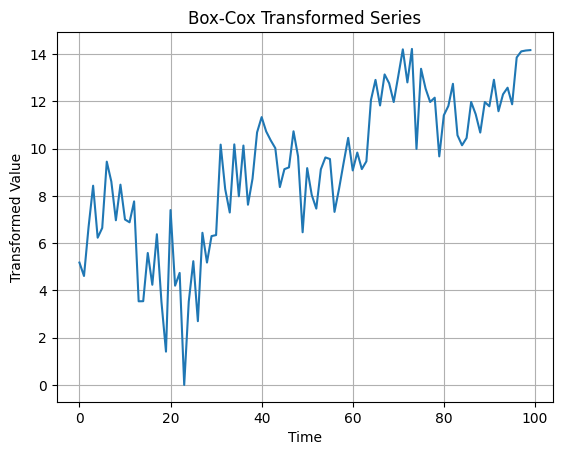

In [ ]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from arch.unitroot import PhillipsPerron
import numpy as np

# Ensure y is strictly positive before applying Box-Cox transformation
min_y = np.min(y)
if min_y <= 0:
    y_positive = y + abs(min_y) + 1  # Add constant to make all values > 0
else:
    y_positive = y

y_lissed = boxcox(y_positive, lmbda=0.5)
plt.plot(y_lissed)

adf_result = adfuller(y_lissed)
adf_pvalue = adf_result[1] # Extract p-value here
if adf_pvalue <= 0.05:
    print("  Result (ADF): The series is likely stationary. ✅")
else:
    print("  Result (ADF): The series is likely non-stationary. ❌")

pp_result = PhillipsPerron(y_lissed)
pp_pvalue = pp_result.pvalue # Extract p-value here
if pp_pvalue <= 0.05:
    print("  Result (PP): The series is likely stationary. ✅")
else:
    print("  Result (PP): The series is likely non-stationary. ❌")

plt.title('Box-Cox Transformed Series')
plt.xlabel('Time')
plt.ylabel('Transformed Value')
plt.grid(True)
plt.show()

  Result (ADF): The series is likely stationary. ✅
  Result (PP): The series is likely stationary. ✅


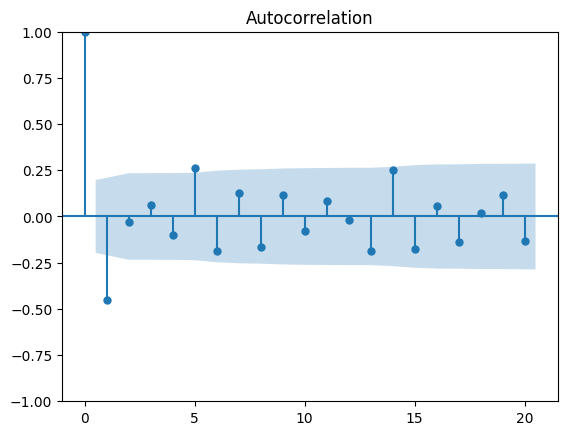

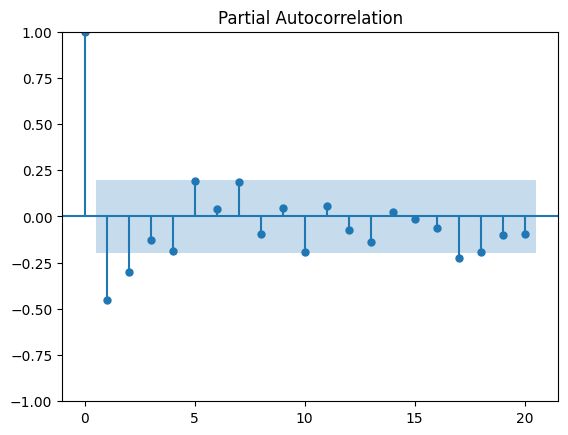

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
y_diff = np.diff(y_lissed, n=1)
plot_acf(y_diff)
plot_pacf(y_diff)
adf_result = adfuller(y_diff)
adf_pvalue = adf_result[1] # Extract p-value here
if adf_pvalue <= 0.05:
    print("  Result (ADF): The series is likely stationary. ✅")
else:
    print("  Result (ADF): The series is likely non-stationary. ❌")

pp_result = PhillipsPerron(y_diff)
pp_pvalue = pp_result.pvalue # Extract p-value here
if pp_pvalue <= 0.05:
    print("  Result (PP): The series is likely stationary. ✅")
else:
    print("  Result (PP): The series is likely non-stationary. ❌")

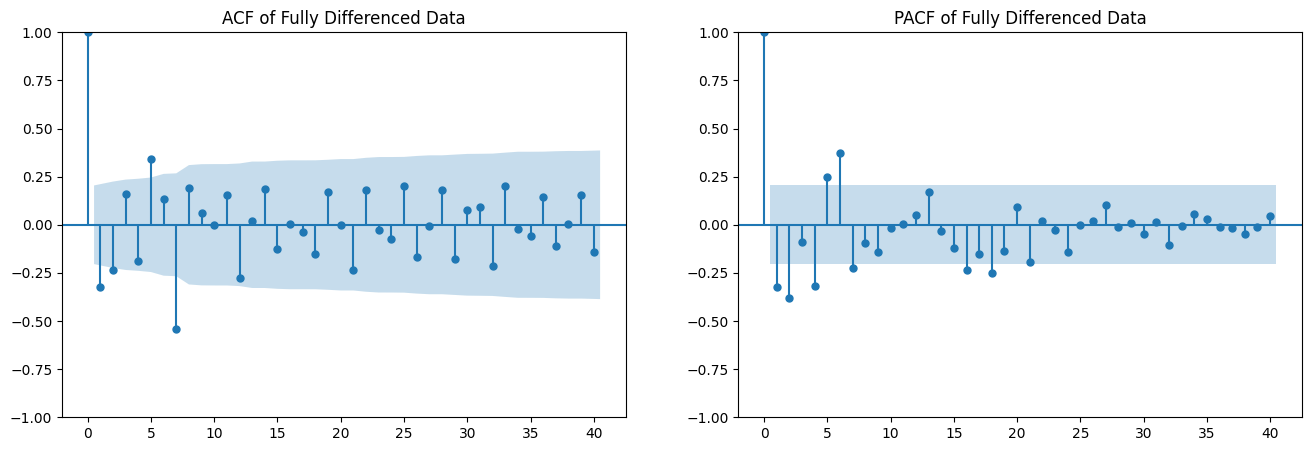

In [ ]:
import numpy as np # Ensure numpy is imported if not already
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt # Import the module with alias sgt
s = 7

# Apply seasonal difference ON TOP of the first difference
# Correction avec pandas (plus simple)
y_fully_differenced = y_diff[7:] - y_diff[:-7]
# OU avec numpy (soustraire le vecteur décalé)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# We use 40 lags to see multiple cycles (7, 14, 21, 28...)
sgt.plot_acf(y_fully_differenced, lags=40, ax=axes[0])
axes[0].set_title('ACF of Fully Differenced Data')

sgt.plot_pacf(y_fully_differenced, lags=40, ax=axes[1])
axes[1].set_title('PACF of Fully Differenced Data')

plt.show()

### so now we can build sarimax

In [ ]:
# Install pmdarima if not already installed
%pip install pmdarima

import pmdarima as pm
train = y_lissed[:-12]
test = y_lissed[-12:]
auto_model = pm.auto_arima(train,
                           seasonal=True, m=7,
                           d=1,  # Force la tendance
                           D=1,  # FORCE la saisonnalité (pour éviter la ligne droite)
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)


print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[7]             : AIC=inf, Time=3.90 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=384.703, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=347.124, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.44 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=377.155, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=348.596, Time=0.49 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=340.937, Time=0.53 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=339.146, Time=0.25 sec
 ARIMA(1,1,0)(0,1,2)[7]             : AIC=341.002, Time=0.77 sec
 ARIMA(1,1,0)(1,1,2)[7]             : AIC=inf, Time=4.35 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=349.761, Time=0.20 sec
 ARIMA(2,1,0)(0,1,1)[7]             : AIC=331.469, Time=0.55 sec
 ARIMA(2,1,0)(0,1,0)[7]             : AIC=367.065, Time=0.12 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=1.30 sec
 ARIMA(2,1,0)(0,1,2)[7]             : AIC=inf, Time=1.19 sec
 A

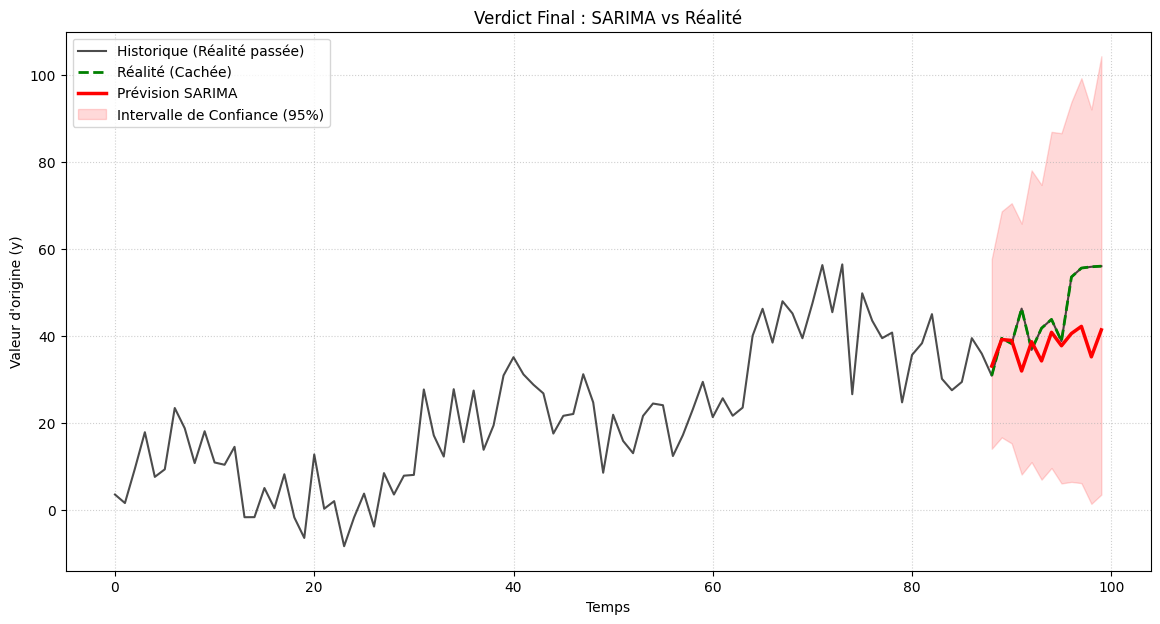

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox # Import direct de la fonction native

# 1. Génération des prédictions (sur les données transformées)
preds_transformed, conf_int_transformed = auto_model.predict(n_periods=12, return_conf_int=True)

# 2. Paramètres de transformation (Lambda de ton Box-Cox précédent)
# Note : Assure-toi que lmbda est bien celui retourné par boxcox()
lmbda = 0.5

# 3. Gestion du décalage (Shift) pour les valeurs positives
min_y_val = np.min(y)
shift_val = abs(min_y_val) + 1 if min_y_val <= 0 else 0

# 4. Inversion Box-Cox propre avec SciPy
# On applique l'inversion puis on retire le décalage (shift)
preds_real = inv_boxcox(preds_transformed, lmbda) - shift_val

# Inversion des bornes de l'intervalle de confiance
conf_int_real_lower = inv_boxcox(conf_int_transformed[:, 0], lmbda) - shift_val
conf_int_real_upper = inv_boxcox(conf_int_transformed[:, 1], lmbda) - shift_val

# Inversion du jeu de test pour la comparaison
actual_test_real = inv_boxcox(test, lmbda) - shift_val

# 5. Visualisation du verdict final
t_test = t[-len(test):]

plt.figure(figsize=(14, 7))
plt.plot(t, y, label="Historique (Réalité passée)", color='black', alpha=0.7)
plt.plot(t_test, actual_test_real, label="Réalité (Cachée)", color='green', linestyle='--', linewidth=2)
plt.plot(t_test, preds_real, label="Prévision SARIMA", color='red', linewidth=2.5)

# Zone d'incertitude
plt.fill_between(t_test, conf_int_real_lower, conf_int_real_upper, color='red', alpha=0.15, label="Intervalle de Confiance (95%)")

plt.title("Verdict Final : SARIMA vs Réalité")
plt.xlabel('Temps')
plt.ylabel('Valeur d\'origine (y)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


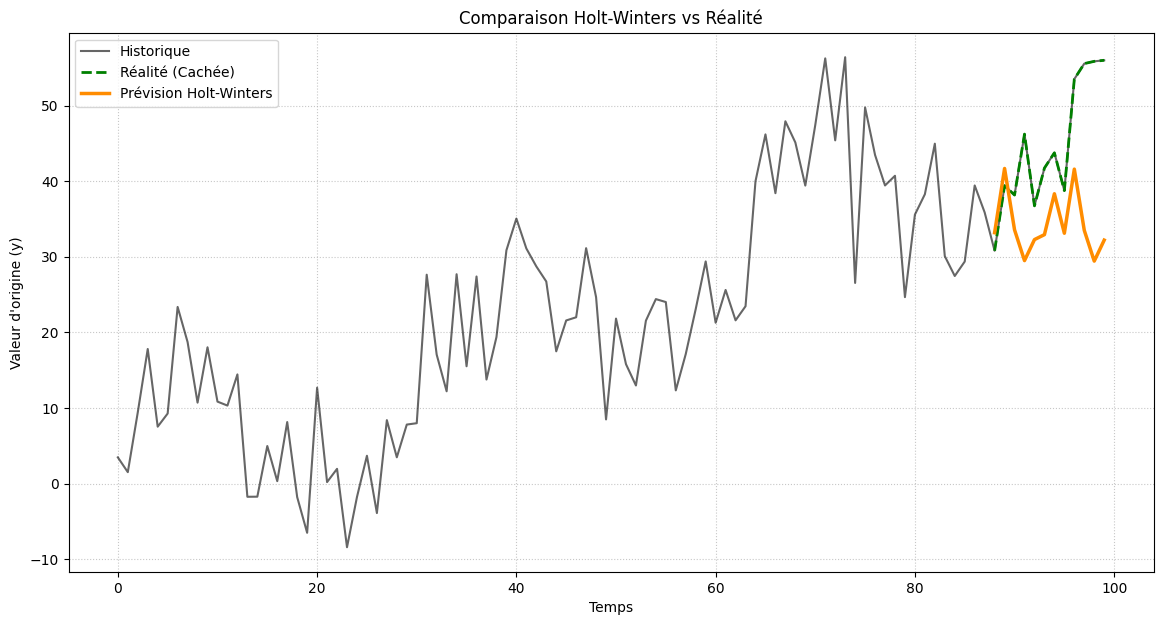

In [ ]:
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# On passe en 'mul' pour la saisonnalité si les vagues s'amplifient
# Add a small epsilon to 'train' to ensure all values are strictly positive for multiplicative seasonality
model_hw = ExponentialSmoothing(train + 1e-6,
                                trend='add',
                                seasonal='mul', # Teste 'mul' ici
                                seasonal_periods=7,
                                initialization_method="estimated").fit()

preds_hw_transformed = model_hw.forecast(12)

# Inversion (Vérifie bien que lmbda et shift_val sont les bons !)
preds_hw_real = inv_boxcox(preds_hw_transformed, lmbda) - shift_val

# 4. Visualisation
plt.figure(figsize=(14, 7))

# Plot des données historiques
plt.plot(t, y, label="Historique", color='black', alpha=0.6)

# Plot de la réalité (Test Set)
plt.plot(t_test, actual_test_real, label="Réalité (Cachée)", color='green', linestyle='--', linewidth=2)

# Plot des prévisions Holt-Winters
plt.plot(t_test, preds_hw_real, label="Prévision Holt-Winters", color='darkorange', linewidth=2.5)

plt.title("Comparaison Holt-Winters vs Réalité")
plt.xlabel('Temps')
plt.ylabel('Valeur d\'origine (y)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

<h1>ML Prediction<h1>

In [ ]:
#Intializing the axes
df = pd.DataFrame({'y': y_lissed})

# 2. Création des caractéristiques (Lags)
df['lag_1'] = df['y'].shift(1)   # Valeur d'hier
df['lag_2'] = df['y'].shift(2)   # Valeur d'avant-hier
df['lag_7'] = df['y'].shift(7)   # Valeur de la semaine dernière (Crucial pour toi !)

# 3. Statistiques glissantes
df['moy_mobile_3'] = df['y'].shift(1).rolling(window=3).mean()

# 4. Suppression des lignes avec des NaN (créés par les shifts)
df.dropna(inplace=True)

# 5. INITIALISATION DES AXES
X = df.drop('y', axis=1) # Toutes les colonnes sauf la cible
y_target = df['y']       # La colonne cible

# 6. Split Chronologique (pas de shuffle !)
X_train, X_test = X[:-12], X[-12:]
y_train, y_test = y_target[:-12], y_target[-12:]

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso # Import Lasso if intended
from xgboost import XGBRegressor
from sklearn.svm import SVR # Corrected typo: 'sklearm' to 'sklearn'
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np # Ensure numpy is imported

# Standardization
Scaler_X = StandardScaler()
Scaler_y = StandardScaler()

X_train_scaled = Scaler_X.fit_transform(X_train)
y_train_scaled = Scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten() # Corrected assignment and variable name
X_test_scaled = Scaler_X.transform(X_test) # Scale X_test for predictions

# Creation des model
models = {
    "Linear Regression": LinearRegression(), # Removed 'reg = \'lasso\'', use Lasso() if that's what's intended
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
    "Support Vector Regression": SVR(kernel='rbf', C=100, gamma=0.1)
}

results = {}
for name, model in models.items():
    # All models will be fitted on scaled data and predictions will be made on scaled test data
    model.fit(X_train_scaled, y_train_scaled)
    preds_scaled = model.predict(X_test_scaled) # Make predictions on scaled test data

    # Inverse transform y predictions
    preds_trans = Scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

    # Inversion finale du Box-Cox pour revenir à la réalité
    # lmbda and shift_val should be available from previous cells
    preds_real = inv_boxcox(preds_trans, lmbda) - shift_val
    results[name] = preds_real

# Calcul du RMSE pour chaque modèle
actual_real = inv_boxcox(y_test, lmbda) - shift_val # y_test is already unscaled, inverse Box-Cox it
for name, pred in results.items():
    rmse = np.sqrt(mean_squared_error(actual_real, pred))
    print(f"{name} -> RMSE: {rmse:.2f}")

Linear Regression -> RMSE: 7.20
XGBoost -> RMSE: 9.68
Support Vector Regression -> RMSE: 8.46


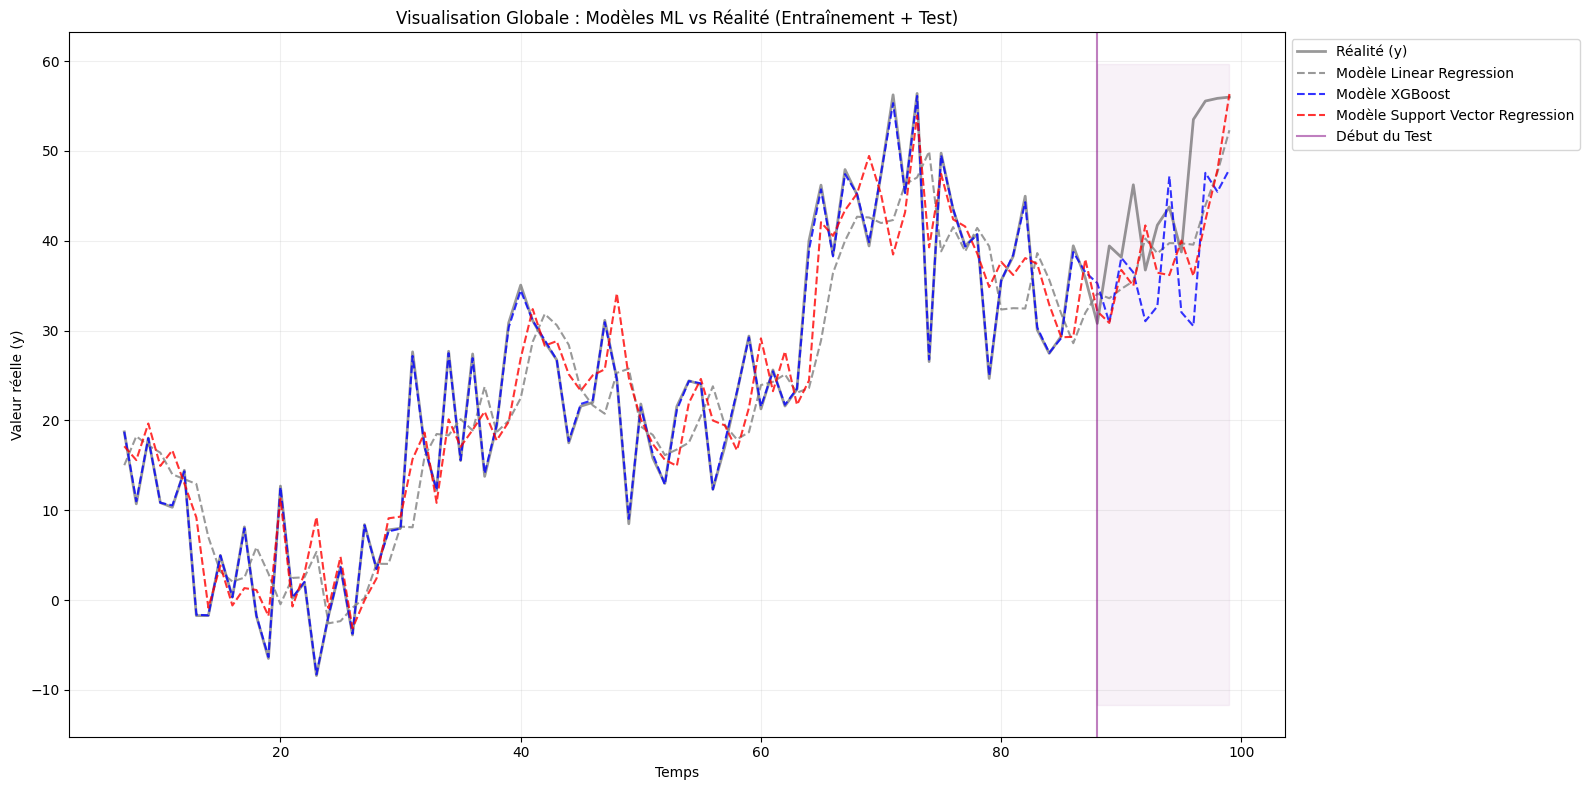

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Initialisation du dictionnaire pour stocker les prédictions complètes
full_results = {}

for name, model in models.items():
    # Fit the model on scaled training data
    model.fit(X_train_scaled, y_train_scaled)

    # Predict on scaled training and test data
    train_preds_scaled = model.predict(X_train_scaled)
    test_preds_scaled = model.predict(X_test_scaled)

    # Inverse transform predictions from scaled y back to y_lissed scale
    train_preds_lissed = Scaler_y.inverse_transform(train_preds_scaled.reshape(-1, 1)).flatten()
    test_preds_lissed = Scaler_y.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()

    # Concatenate train and test predictions (on y_lissed scale)
    full_preds_lissed = np.concatenate([train_preds_lissed, test_preds_lissed])

    # Inverse Box-Cox transform to original 'y' scale
    full_results[name] = inv_boxcox(full_preds_lissed, lmbda) - shift_val

# 3. Création des axes temporels
# On récupère l'index du DataFrame original pour l'alignement
t_full = df.index # Corrected df_ml to df

plt.figure(figsize=(16, 8))

# --- Tracé de la Réalité ---
# df['y'] is y_lissed, so inverse transform it to original scale for plotting
real_y_original_scale = inv_boxcox(df['y'], lmbda) - shift_val
plt.plot(t_full, real_y_original_scale, label="Réalité (y)", color='black', alpha=0.4, linewidth=2)

# --- Tracé des Modèles ---
colors = {'Linear Regression': 'gray', 'XGBoost': 'blue', 'Support Vector Regression': 'red'}

for name, preds_real_scale in full_results.items():
    plt.plot(t_full, preds_real_scale, label=f"Modèle {name}", color=colors[name], linestyle='--', alpha=0.8)

# --- Mise en évidence de la zone de Test ---
# The split point for t_full is where the training data ends and test data begins.
plt.axvline(x=t_full[len(X_train)], color='purple', linestyle='-', alpha=0.5, label="Début du Test")
plt.fill_between(t_full[-12:], plt.ylim()[0], plt.ylim()[1], color='purple', alpha=0.05)

plt.title("Visualisation Globale : Modèles ML vs Réalité (Entraînement + Test)")
plt.xlabel("Temps")
plt.ylabel("Valeur réelle (y)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Légende à l'extérieur pour plus de clarté
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

<h1>Deep learning <h1>

In [ ]:
#Using normal NN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Construction du modèle "Deep Stage 1"
model_nn = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]), # Couche d'entrée
    Dropout(0.2), # Pour éviter l'overfitting
    Dense(32, activation='relu'), # Couche cachée
    Dense(1) # Sortie : une seule valeur (notre prédiction y)
])

model_nn.compile(optimizer='adam', loss='mse')

# Entraînement (sur les données scalées X_train_scaled)
history = model_nn.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=8, verbose=0)

# Prédiction et inversion du scale
preds_nn_scaled = model_nn.predict(X_test_scaled)

# Fit scaler_y here if it hasn't been fitted already (due to previous cell inconsistency)
# This ensures scaler_y is ready for inverse_transform
scaler_y.fit(y_train.values.reshape(-1, 1)) # Fit on the original y_train data

preds_nn = scaler_y.inverse_transform(preds_nn_scaled).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


In [ ]:
# Install the correct Deep Forest regressor
!pip install deepforest


In [ ]:
!pip install git+https://github.com/LAMDA-NJU/Deep-Forest.git

  Cloning https://github.com/LAMDA-NJU/Deep-Forest.git to /tmp/pip-req-build-7vy95xok
  Running command git clone --filter=blob:none --quiet https://github.com/LAMDA-NJU/Deep-Forest.git /tmp/pip-req-build-7vy95xok
  Resolved https://github.com/LAMDA-NJU/Deep-Forest.git to commit 50485148da262872eb1d24d09bcb0c874ae50fea
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

# ─────────────────────────────────────────
# Classe gcForest / Cascade Forest
# ─────────────────────────────────────────
class CascadeForestRegressor:
    def __init__(self, n_layers=3, n_trees=100, random_state=42):
        self.n_layers   = n_layers
        self.n_trees    = n_trees
        self.random_state = random_state
        self.layers     = []

    def _build_layer(self):
        return [
            RandomForestRegressor(n_estimators=self.n_trees, random_state=self.random_state),
            RandomForestRegressor(n_estimators=self.n_trees, random_state=self.random_state+1),
            ExtraTreesRegressor (n_estimators=self.n_trees, random_state=self.random_state+2),
            ExtraTreesRegressor (n_estimators=self.n_trees, random_state=self.random_state+3),
        ]

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        current_X = X.copy()

        for i in range(self.n_layers):
            layer = self._build_layer()
            oof_preds = []

            for model in layer:
                # out-of-fold → évite le data leakage entre niveaux
                oof = cross_val_predict(model, current_X, y, cv=3)
                model.fit(current_X, y)
                oof_preds.append(oof.reshape(-1, 1))

            # nouvelle représentation = features originales + prédictions OOF
            augmented  = np.hstack(oof_preds)           # (n, 4)
            current_X  = np.hstack([X, augmented])       # (n, features + 4)

            print(f"  [Layer {i+1}] shape entrée → {current_X.shape}")
            self.layers.append(layer)

        self._X_orig_cols = X.shape[1]
        return self

    def predict(self, X):
        X = np.array(X)
        current_X = X.copy()

        for layer in self.layers:
            preds = [m.predict(current_X).reshape(-1,1) for m in layer]
            augmented = np.hstack(preds)
            current_X = np.hstack([X, augmented])

        # moyenne finale des 4 forêts du dernier niveau
        final = np.hstack([
            m.predict(current_X).reshape(-1,1) for m in self.layers[-1]
        ])
        return final.mean(axis=1)


# ─────────────────────────────────────────
# Utilisation
# ─────────────────────────────────────────
model = CascadeForestRegressor(n_layers=3, n_trees=100, random_state=42)

print("=== Entraînement gcForest ===")
model.fit(X_train.values, y_train.values)

print("\n=== Prédiction ===")
y_pred = model.predict(X_test.values)

rmse = np.sqrt(mean_squared_error(y_test.values, y_pred))
print(f"\nRMSE gcForest : {rmse:.4f}")

=== Entraînement gcForest ===
  [Layer 1] shape entrée → (81, 8)
  [Layer 2] shape entrée → (81, 8)
  [Layer 3] shape entrée → (81, 8)

=== Prédiction ===

RMSE gcForest : 1.4926


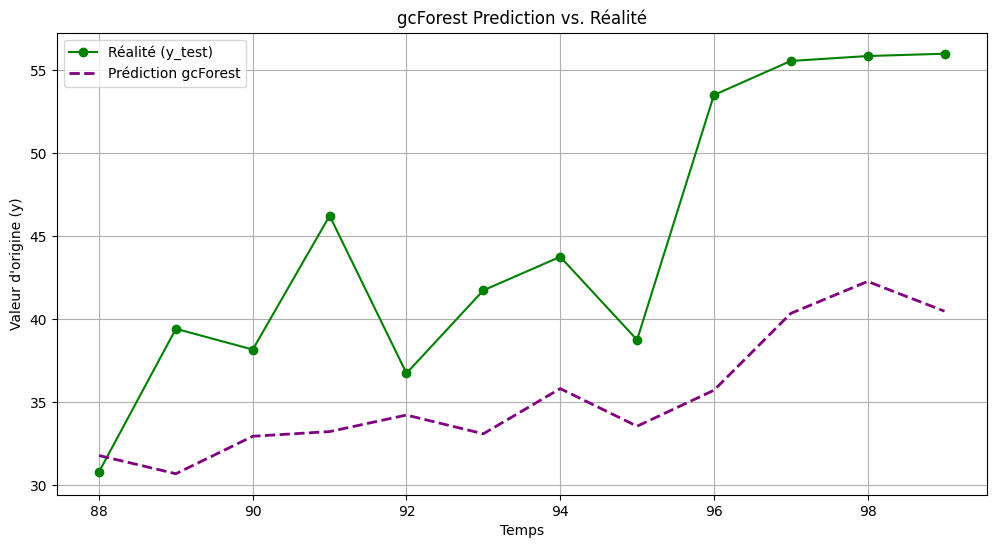

RMSE gcForest (Original Scale) : 10.87


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.special import inv_boxcox

# Ensure lmbda and shift_val are available from previous cells
# If not, you might need to redefine them based on the context
# lmbda = 0.5
# min_y_val = np.min(y)
# shift_val = abs(min_y_val) + 1 if min_y_val <= 0 else 0

# Inverse transform y_test (which is in y_lissed scale) to original scale
actual_real_gcforest = inv_boxcox(y_test, lmbda) - shift_val
# Inverse transform gcForest predictions (which are also in y_lissed scale) to original scale
preds_gcforest_real = inv_boxcox(y_pred, lmbda) - shift_val

plt.figure(figsize=(12, 6))
plt.plot(t_test, actual_real_gcforest, label="Réalité (y_test)", color='green', marker='o')
plt.plot(t_test, preds_gcforest_real, label="Prédiction gcForest", color='purple', linestyle='--', linewidth=2)

plt.title("gcForest Prediction vs. Réalité")
plt.xlabel('Temps')
plt.ylabel('Valeur d\'origine (y)')
plt.legend()
plt.grid(True)
plt.show()

# Calculate and print RMSE for gcForest on the original scale
rmse_gcforest_real = np.sqrt(mean_squared_error(actual_real_gcforest, preds_gcforest_real))
print(f"RMSE gcForest (Original Scale) : {rmse_gcforest_real:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


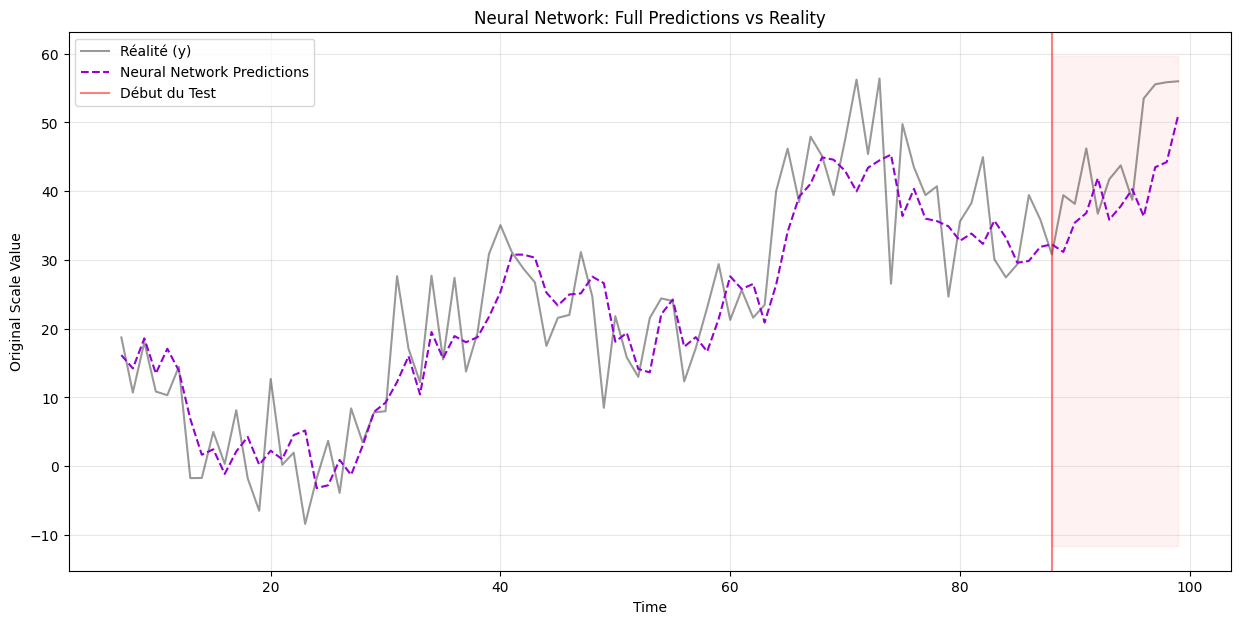

RMSE Neural Network (Test Set): 8.49


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. Define and Train the Model
model_nn_cell = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_nn_cell.compile(optimizer='adam', loss='mse')
model_nn_cell.fit(X_train_scaled, y_train_scaled, epochs=100, batch_size=8, verbose=0)

# 2. Predictions (on scaled scale)
preds_train_scaled = model_nn_cell.predict(X_train_scaled).flatten()
preds_test_scaled = model_nn_cell.predict(X_test_scaled).flatten()

# 3. Inverse Scaling to y_lissed scale
# Note: Scaler_y was fitted in previous ML cells
preds_train_lissed = Scaler_y.inverse_transform(preds_train_scaled.reshape(-1, 1)).flatten()
preds_test_lissed = Scaler_y.inverse_transform(preds_test_scaled.reshape(-1, 1)).flatten()

# 4. Final Inverse Box-Cox to original scale
full_preds_lissed = np.concatenate([preds_train_lissed, preds_test_lissed])
preds_nn_final = inv_boxcox(full_preds_lissed, lmbda) - shift_val

# 5. Plotting
plt.figure(figsize=(15, 7))
real_y_original = inv_boxcox(df['y'], lmbda) - shift_val
plt.plot(df.index, real_y_original, label='Réalité (y)', color='black', alpha=0.4)
plt.plot(df.index, preds_nn_final, label='Neural Network Predictions', color='darkviolet', linestyle='--')

plt.axvline(x=df.index[len(X_train)], color='red', linestyle='-', alpha=0.5, label='Début du Test')
plt.fill_between(df.index[-12:], plt.ylim()[0], plt.ylim()[1], color='red', alpha=0.05)

plt.title('Neural Network: Full Predictions vs Reality')
plt.xlabel('Time')
plt.ylabel('Original Scale Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Score
rmse_nn = np.sqrt(mean_squared_error(real_y_original[-12:], preds_nn_final[-12:]))
print(f'RMSE Neural Network (Test Set): {rmse_nn:.2f}')

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


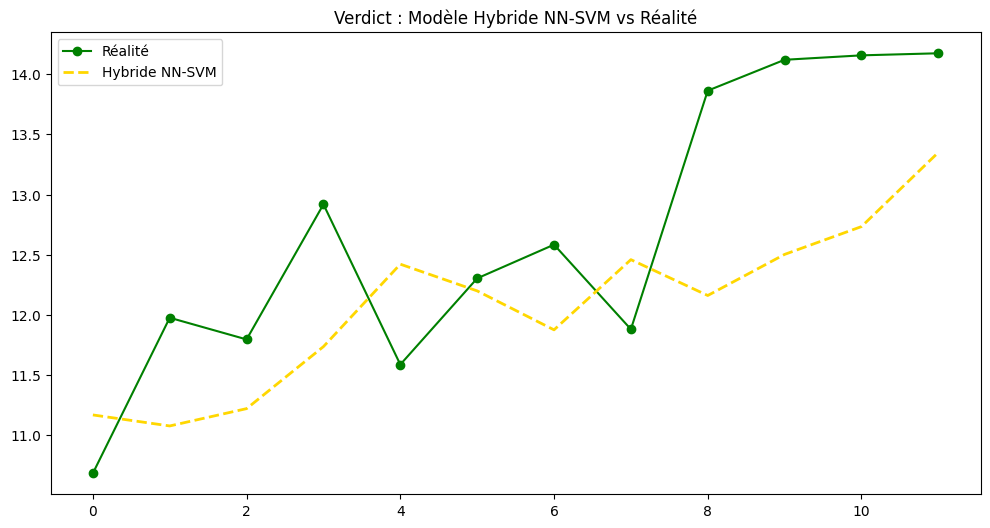

RMSE Hybride NN-SVM : 1.02


In [ ]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.svm import SVR

# 1. Définir l'architecture du NN
input_layer = Input(shape=(X_train.shape[1],))
hidden1 = Dense(64, activation='relu')(input_layer)
# C'est cette couche qui va créer nos nouvelles "features"
feature_layer = Dense(32, activation='relu', name='feature_extraction')(hidden1)
output_layer = Dense(1)(feature_layer)

# Modèle complet pour l'entraînement
nn_model = Model(inputs=input_layer, outputs=output_layer)
nn_model.compile(optimizer='adam', loss='mse')

# 2. Entraîner le NN normalement sur y (brut)
nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, verbose=0)
# Modèle qui s'arrête à la couche de caractéristiques
extractor_model = Model(inputs=nn_model.input,
                        outputs=nn_model.get_layer('feature_extraction').output)

# On transforme nos X_train et X_test en nouveaux vecteurs de dimension 32
X_train_features = extractor_model.predict(X_train_scaled)
X_test_features = extractor_model.predict(X_test_scaled)
# 3. Initialiser et entraîner le SVR sur les features du NN
hybrid_svr = SVR(kernel='rbf', C=10, epsilon=0.1)
hybrid_svr.fit(X_train_features, y_train_scaled)

# 4. Prédiction finale
preds_hybrid_scaled = hybrid_svr.predict(X_test_features)

# Inversion du scaling pour revenir à y d'origine
preds_hybrid = scaler_y.inverse_transform(preds_hybrid_scaled.reshape(-1, 1)).flatten()
plt.figure(figsize=(12, 6))
plt.plot(range(12), y_test, label="Réalité", color='green', marker='o')
plt.plot(range(12), preds_hybrid, label="Hybride NN-SVM", color='gold', linestyle='--', linewidth=2)

plt.title("Verdict : Modèle Hybride NN-SVM vs Réalité")
plt.legend()
plt.show()

rmse_hybrid = np.sqrt(mean_squared_error(y_test, preds_hybrid))
print(f"RMSE Hybride NN-SVM : {rmse_hybrid:.2f}")

In [ ]:
all_predictions = {}

# 2. Add full_results (Linear Regression, XGBoost, SVR) to all_predictions
for model_name, predictions in full_results.items():
    all_predictions[model_name] = predictions

# 3. Add Neural Network predictions (already on original scale) to all_predictions
# The 'preds_nn_full' variable already contains the full predictions (train + test) on the original scale
all_predictions['Neural Network'] = preds_nn_final

# 4. Generate predictions for the training set using the trained gcForest model
train_preds_gcforest_lissed = model.predict(X_train.values)

# 5. Concatenate train and test predictions for gcForest (on Box-Cox transformed scale)
full_preds_gcforest_lissed = np.concatenate([train_preds_gcforest_lissed, y_pred])

# 6. Inverse Box-Cox transform and shift to get full gcForest predictions on original scale
full_preds_gcforest_real = inv_boxcox(full_preds_gcforest_lissed, lmbda) - shift_val

# 7. Add gcForest predictions to all_predictions
all_predictions['gcForest'] = full_preds_gcforest_real

print("Consolidated predictions into 'all_predictions' dictionary.")
print(f"Models in all_predictions: {list(all_predictions.keys())}")

Consolidated predictions into 'all_predictions' dictionary.
Models in all_predictions: ['Linear Regression', 'XGBoost', 'Support Vector Regression', 'Neural Network', 'gcForest']


**Reasoning**:
Now that all predictions are consolidated into a single dictionary and on the original scale, the next logical step is to visualize them against the actual time series data, clearly differentiating between training and testing periods.



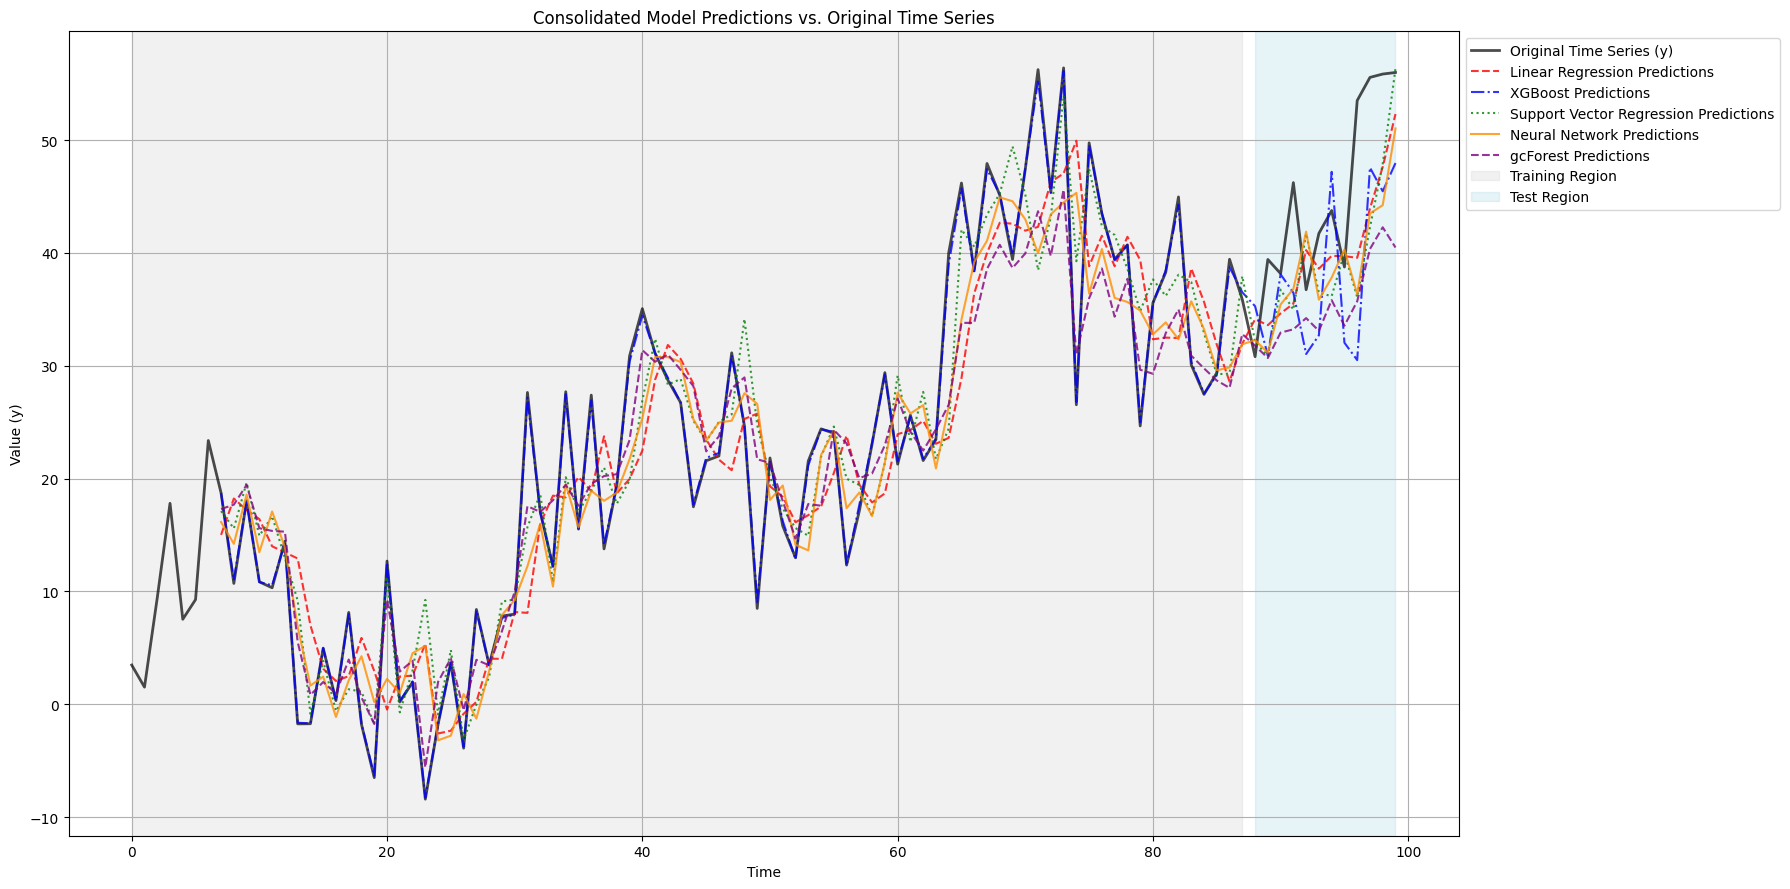

In [ ]:
plt.figure(figsize=(18, 9))

# Plot the original time series 'y'
plt.plot(t, y, label='Original Time Series (y)', color='black', alpha=0.7, linewidth=2)

# Define the split point for training and test data on the original time axis 't'
split_point_index = len(t) - len(y_test) - len(X) + len(X_train) # Adjusting for lag creation and initial df index

# This assumes 'df' starts at index 7 as per previous steps
t_start_df = df.index[0]
t_train_end = df.index[len(X_train) -1] # Last index of X_train in df
t_test_start = df.index[len(X_train)] # First index of X_test in df


# Plot predictions from each model
colors = {
    'Linear Regression': 'red',
    'XGBoost': 'blue',
    'Support Vector Regression': 'green',
    'Neural Network': 'darkorange',
    'gcForest': 'purple'
}

linestyles = {
    'Linear Regression': '--',
    'XGBoost': '-.',
    'Support Vector Regression': ':',
    'Neural Network': '-',
    'gcForest': '--'
}

for model_name, predictions in all_predictions.items():
    # The predictions are aligned with df.index
    plt.plot(df.index, predictions, label=f'{model_name} Predictions', color=colors.get(model_name, 'gray'), linestyle=linestyles.get(model_name, '-'), alpha=0.8)

# Highlight training and test regions
plt.axvspan(t[0], t_train_end, color='lightgray', alpha=0.3, label='Training Region')
plt.axvspan(t_test_start, t[len(t)-1], color='lightblue', alpha=0.3, label='Test Region')

plt.title('Consolidated Model Predictions vs. Original Time Series')
plt.xlabel('Time')
plt.ylabel('Value (y)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()